# Notebook 6 — Write-up & Visualisations

This notebook produces:
1. Publication-quality summary figures
2. A structured written analysis (fill in your observations)
3. **Bonus ablation**: varying number of diffusion steps T
4. Final conclusions

In [36]:
!pip install -q torch torchvision matplotlib numpy tqdm

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math, os, csv
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/diffusion_noise_project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_TYPES = ['gaussian', 'uniform', 'laplace']
COLORS = {'gaussian': '#4C72B0', 'uniform': '#DD8452', 'laplace': '#55A868'}
LABELS = {'gaussian': 'Gaussian (baseline)', 'uniform': 'Uniform', 'laplace': 'Laplace'}

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 150,
})
print('Setup done.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done.


## 1. Load All Saved Figures
Display all figures produced in previous notebooks.

Found 9 figures:
  beta_schedule.png


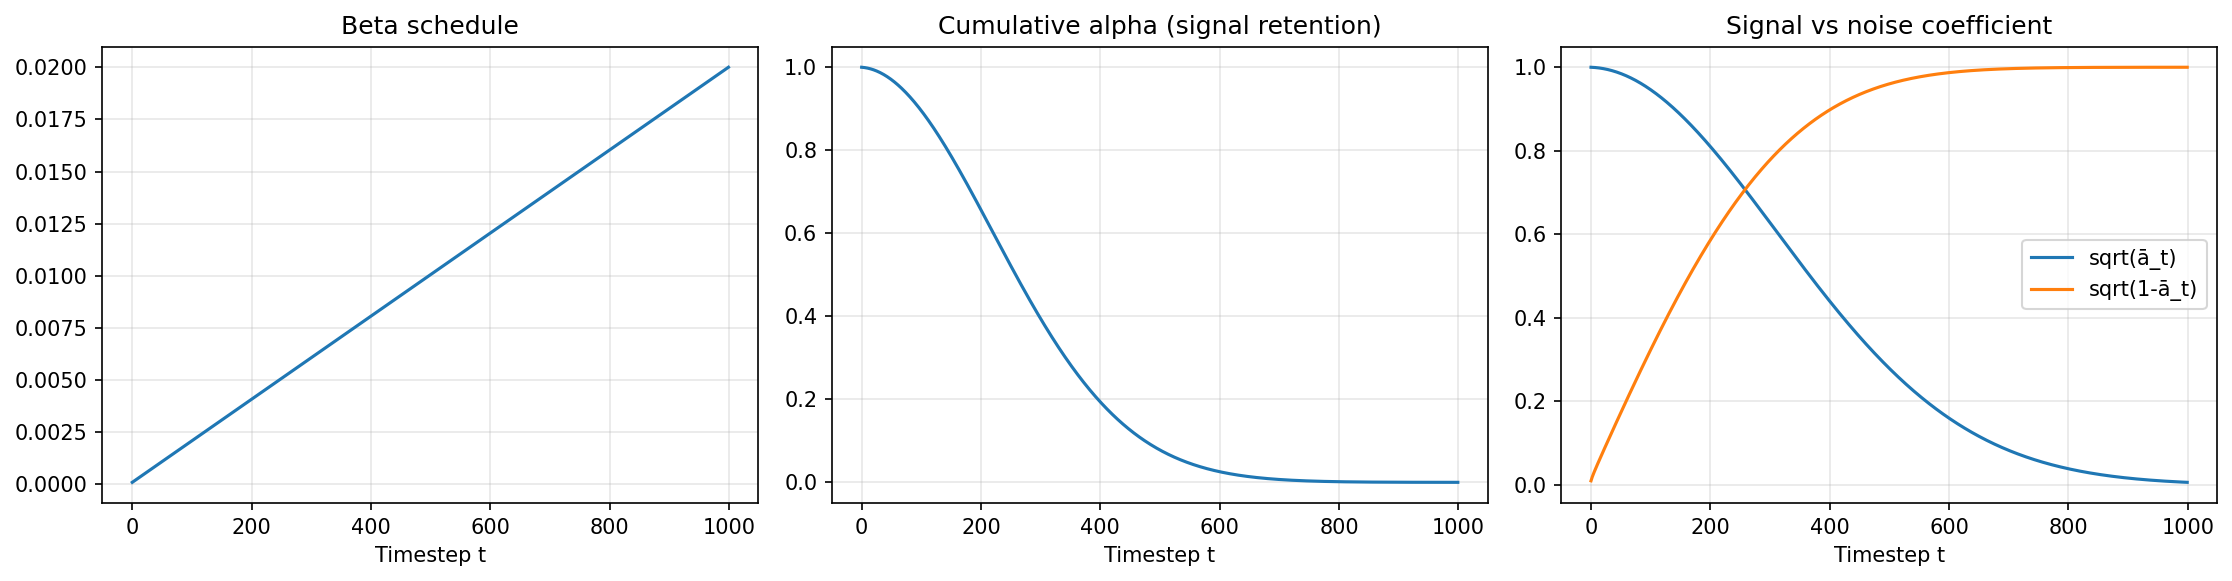

  forward_diffusion_comparison.png


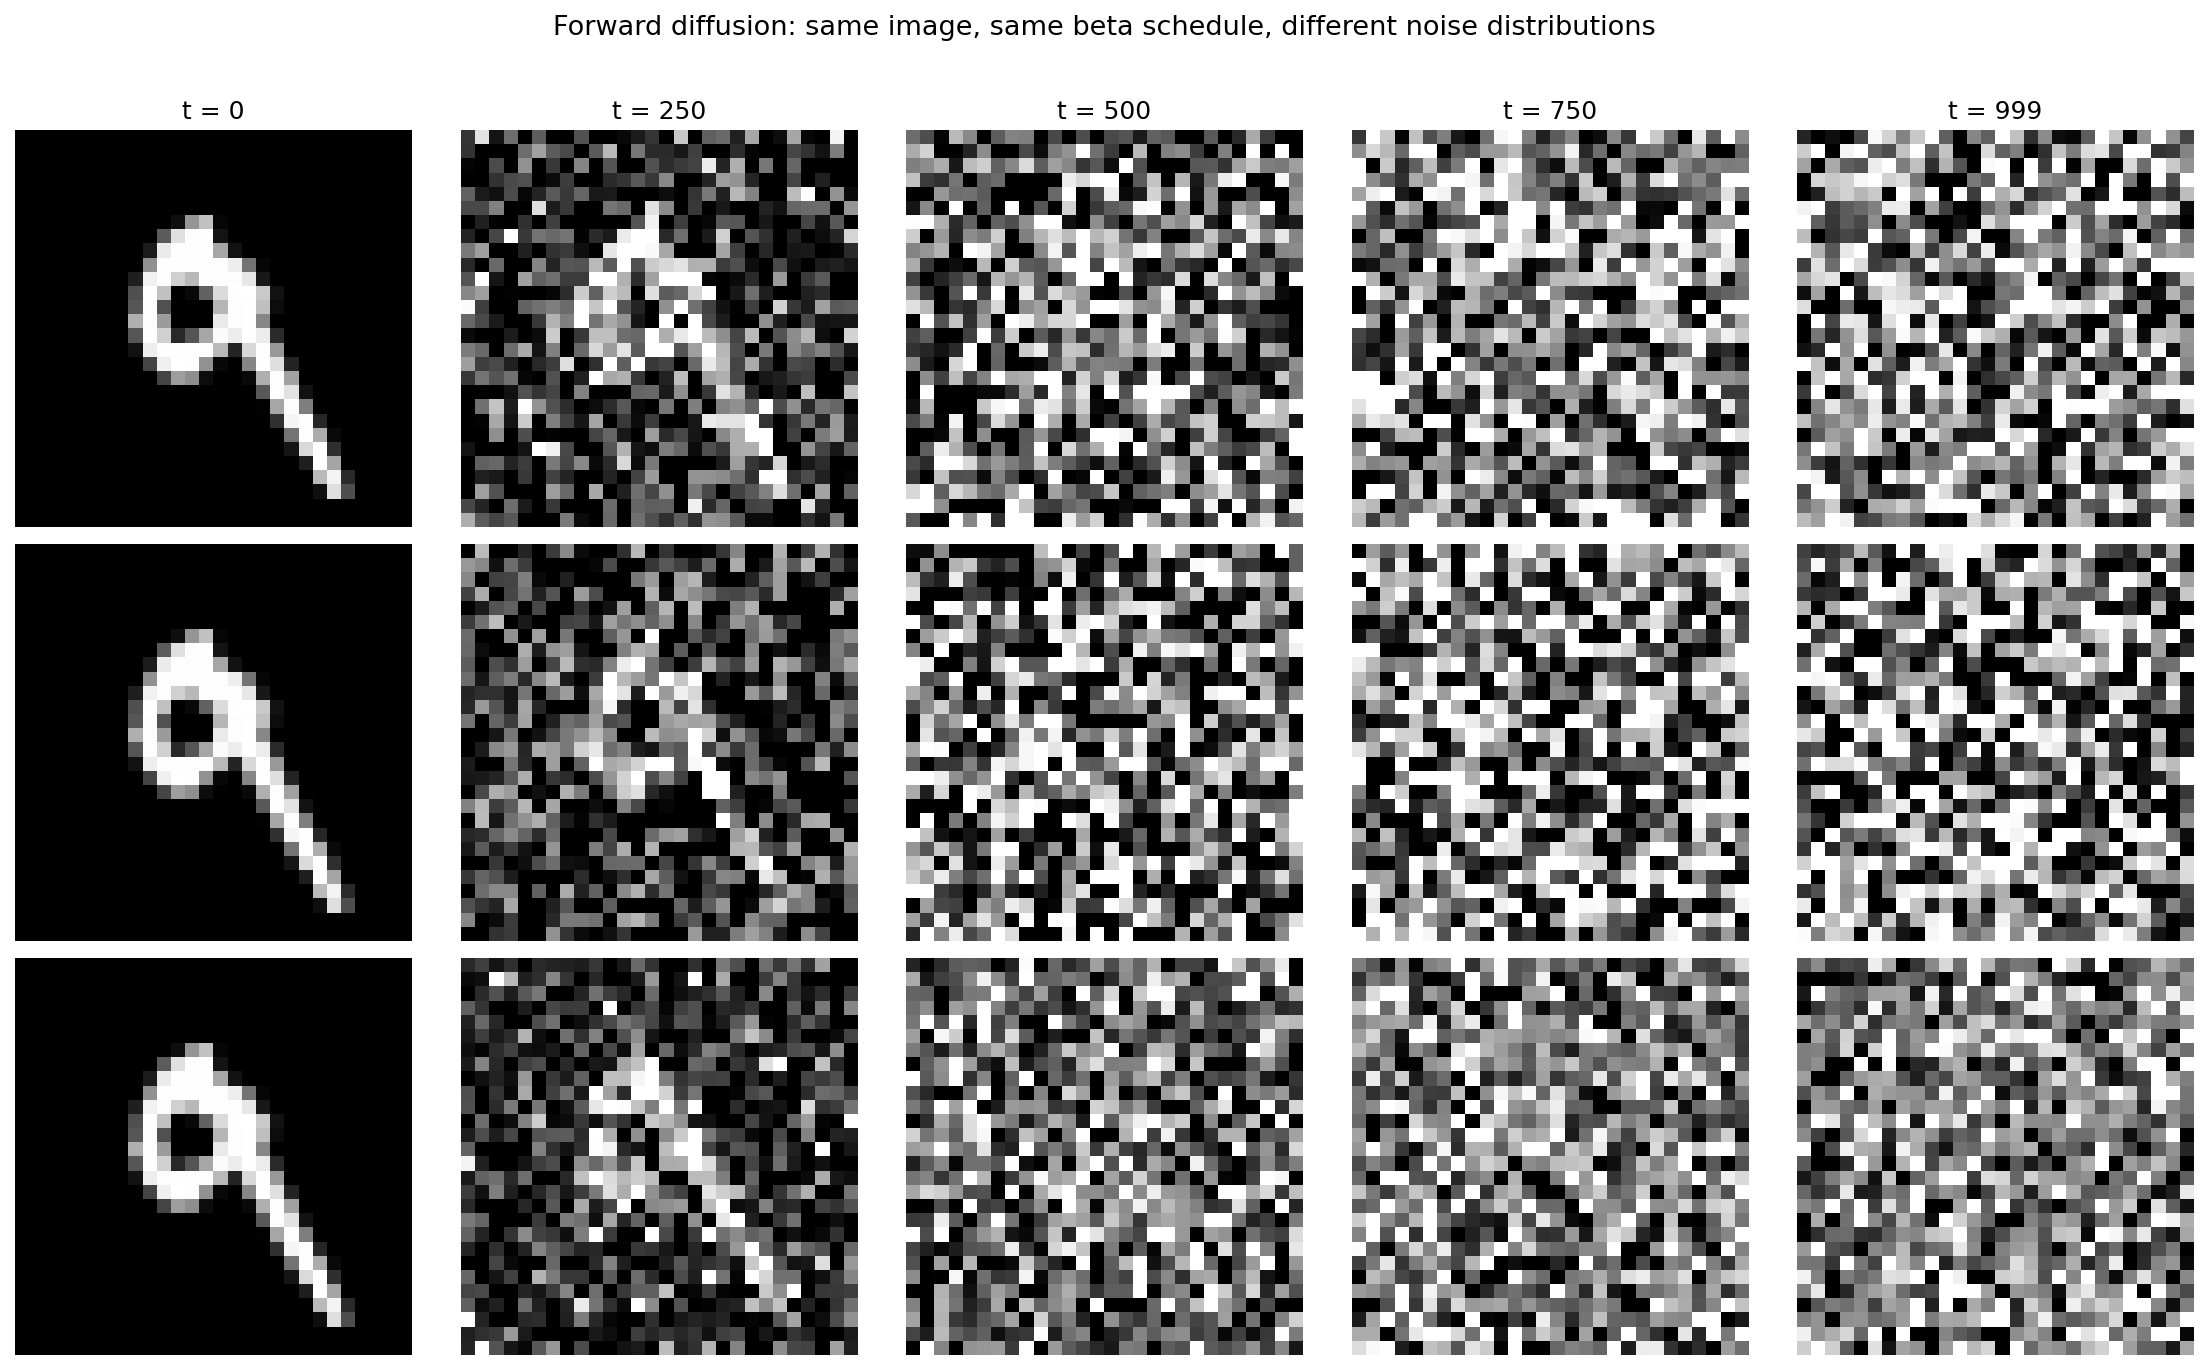

  gaussian_loss.png


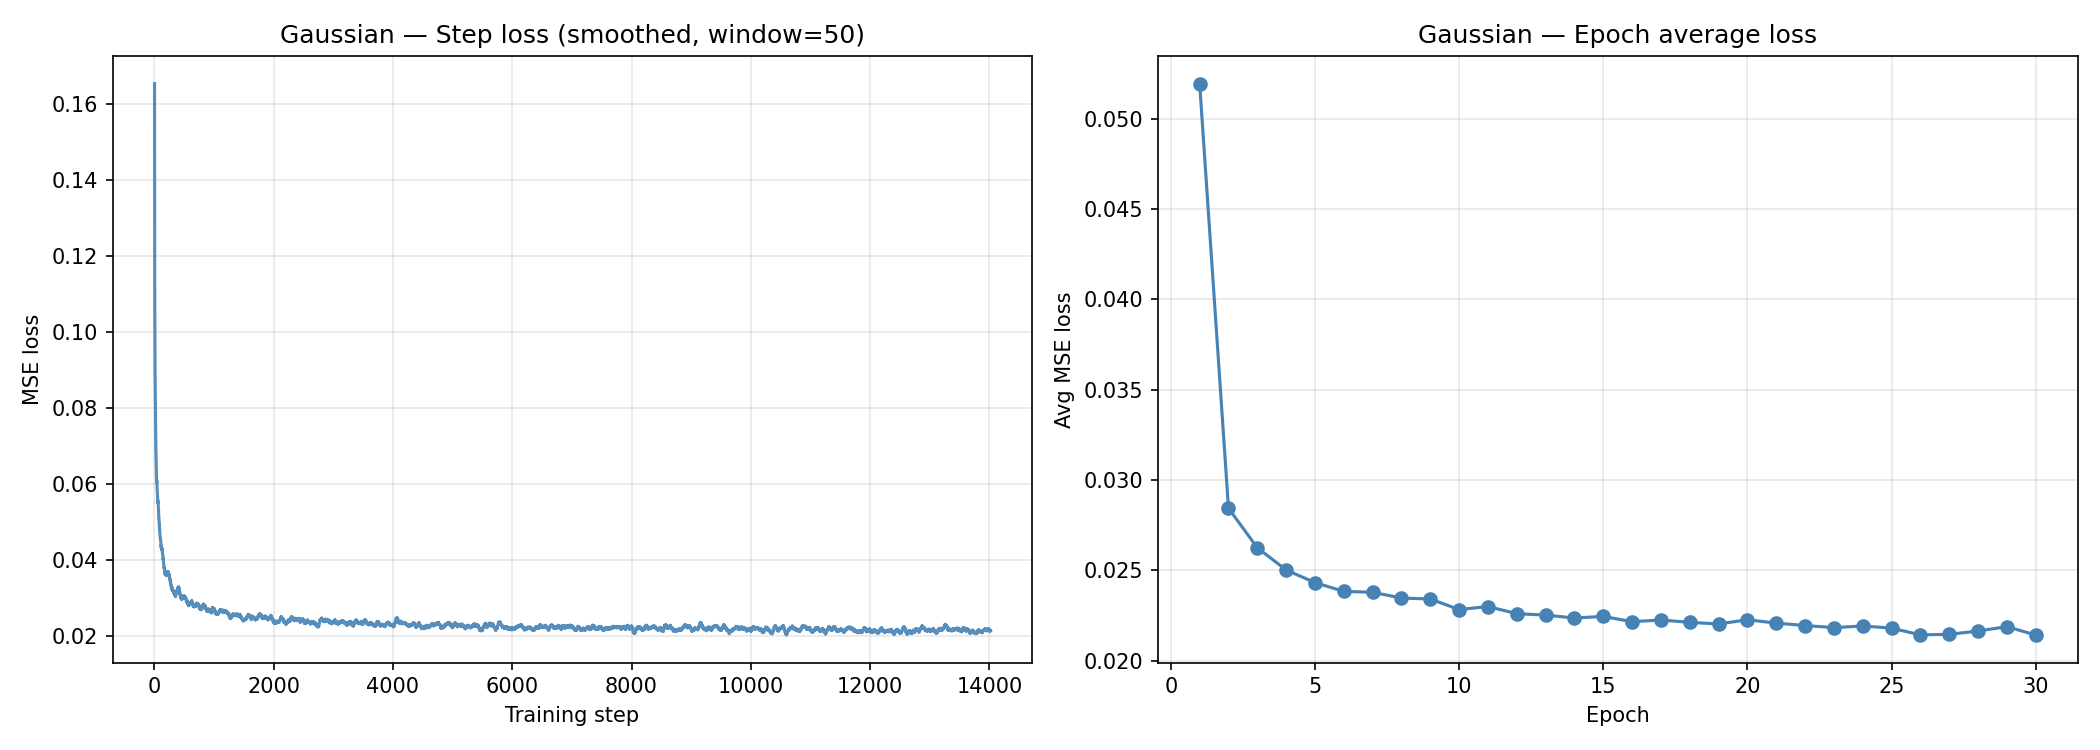

  loss_comparison.png


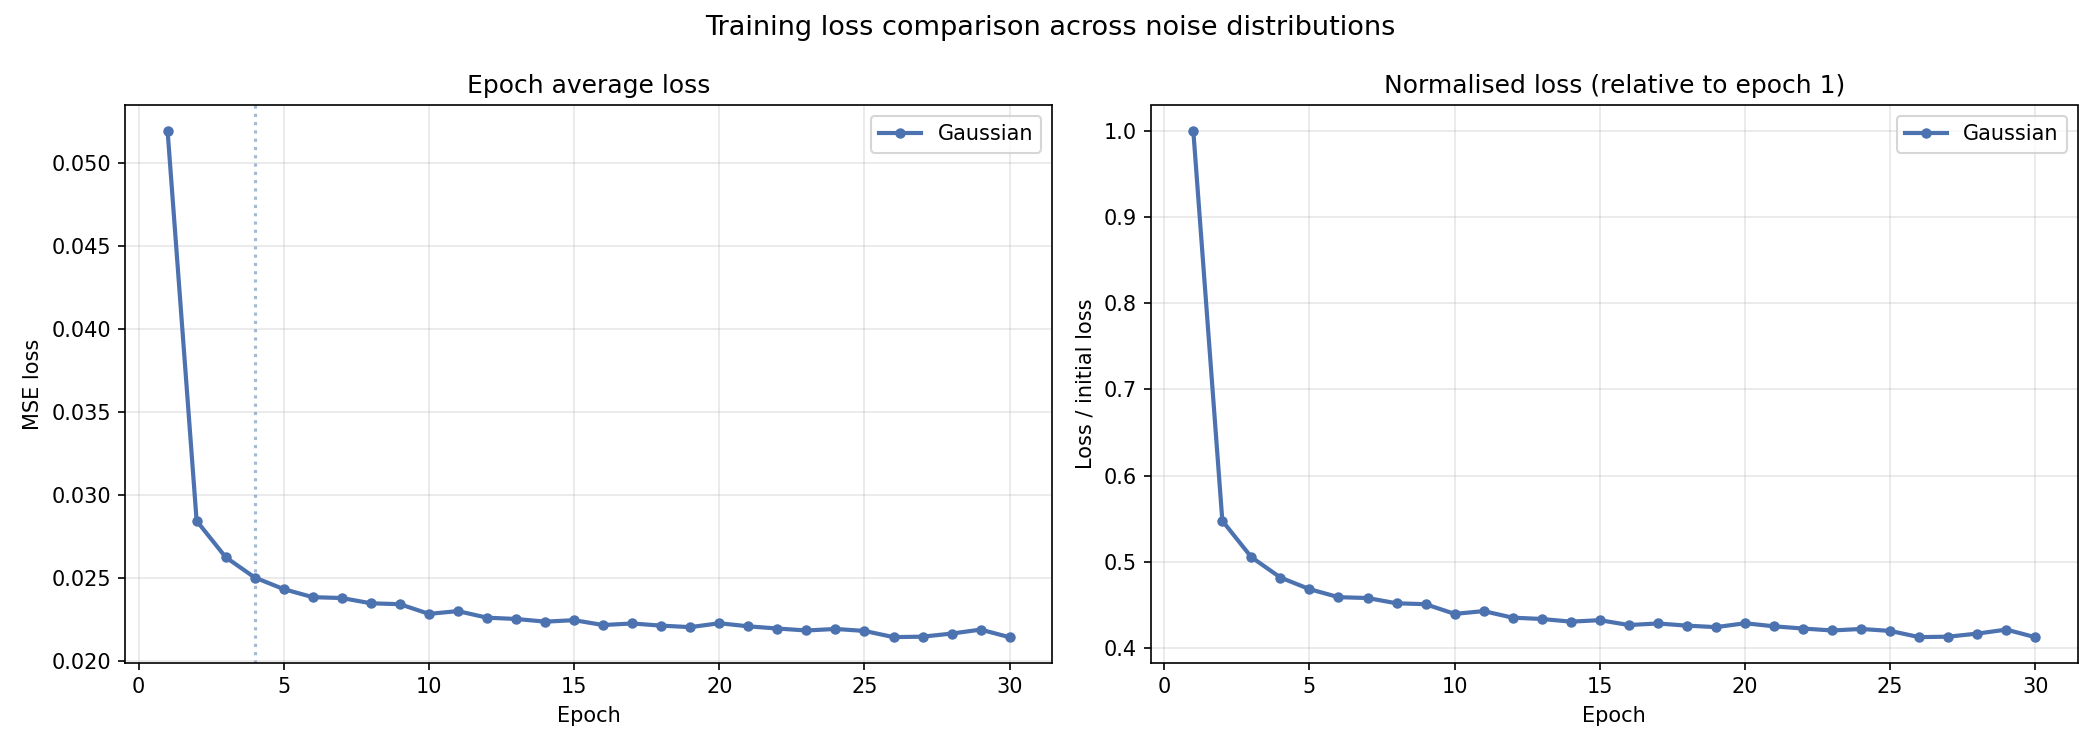

  mnist_samples.png


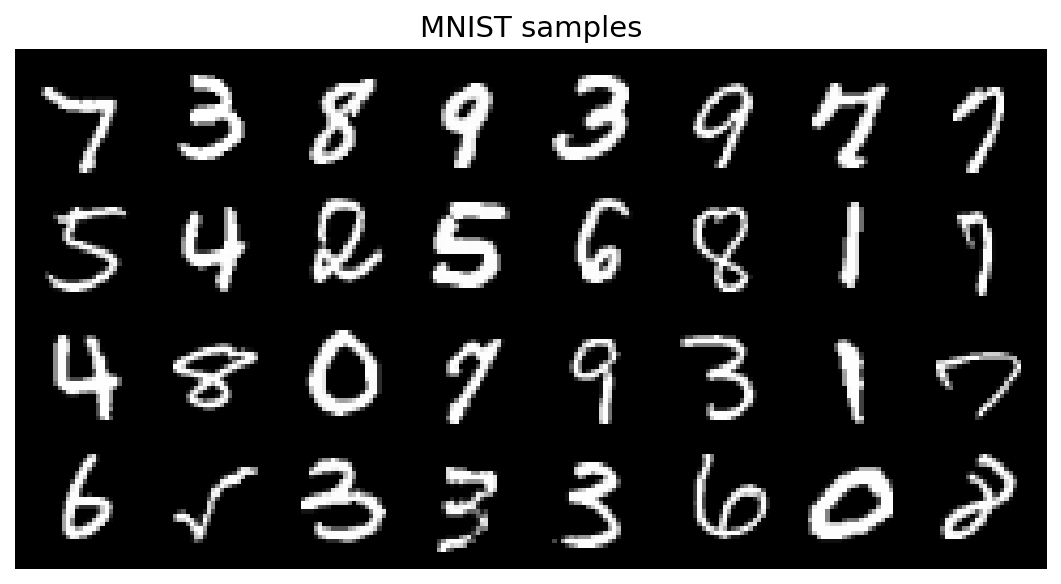

  mse_vs_timestep.png


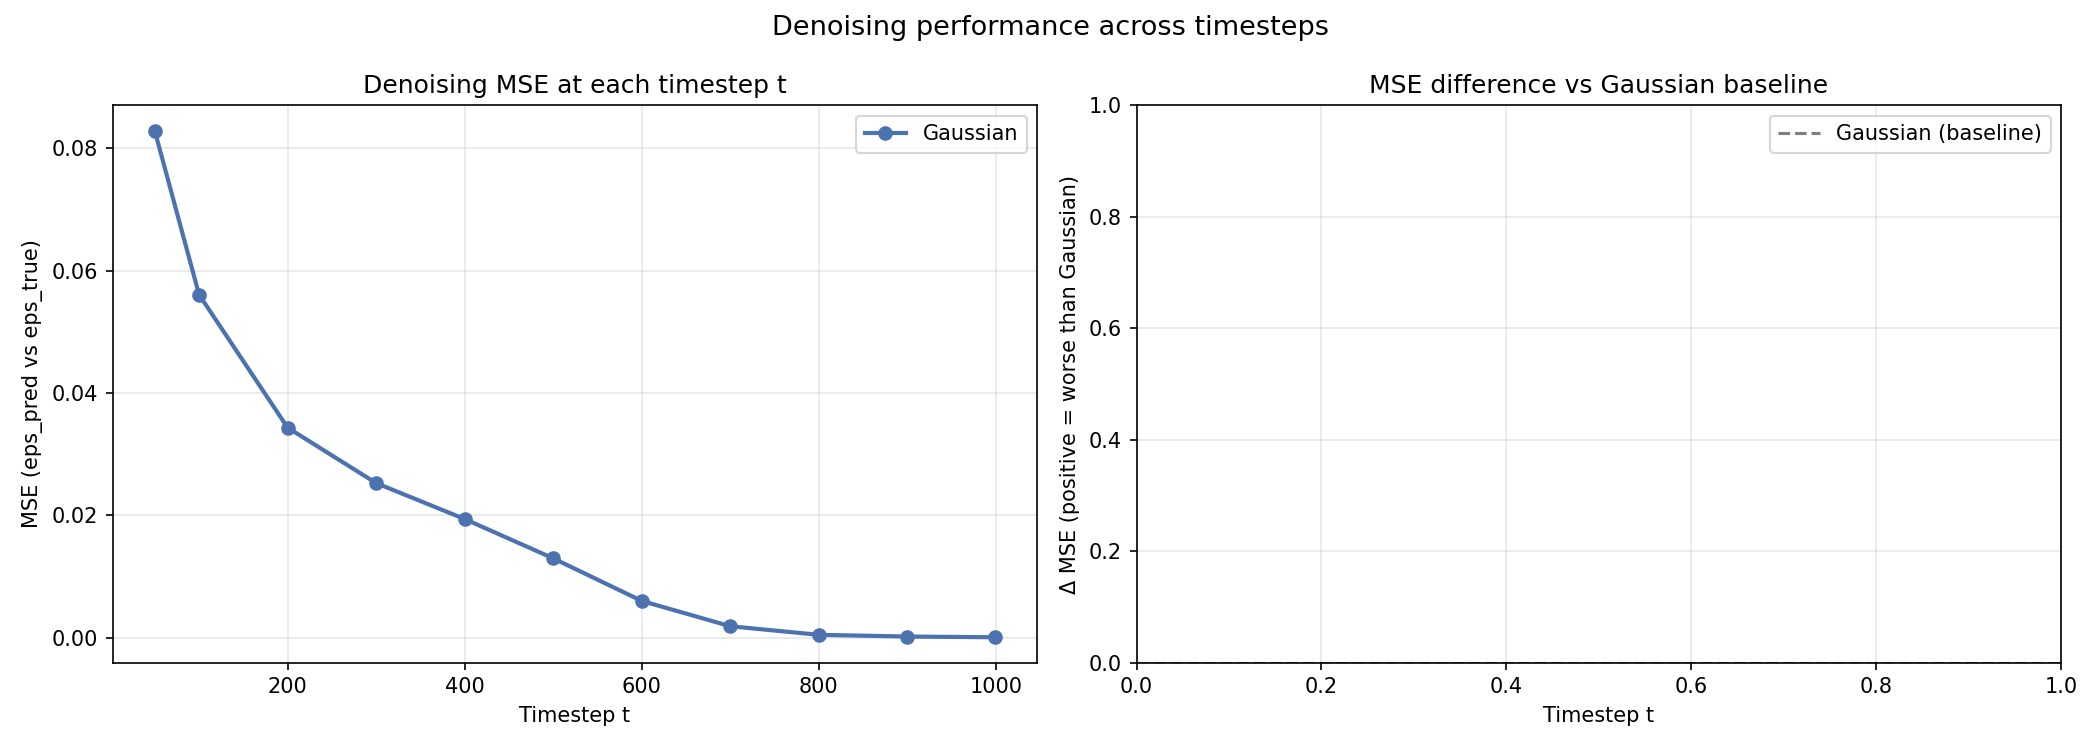

  noise_distributions.png


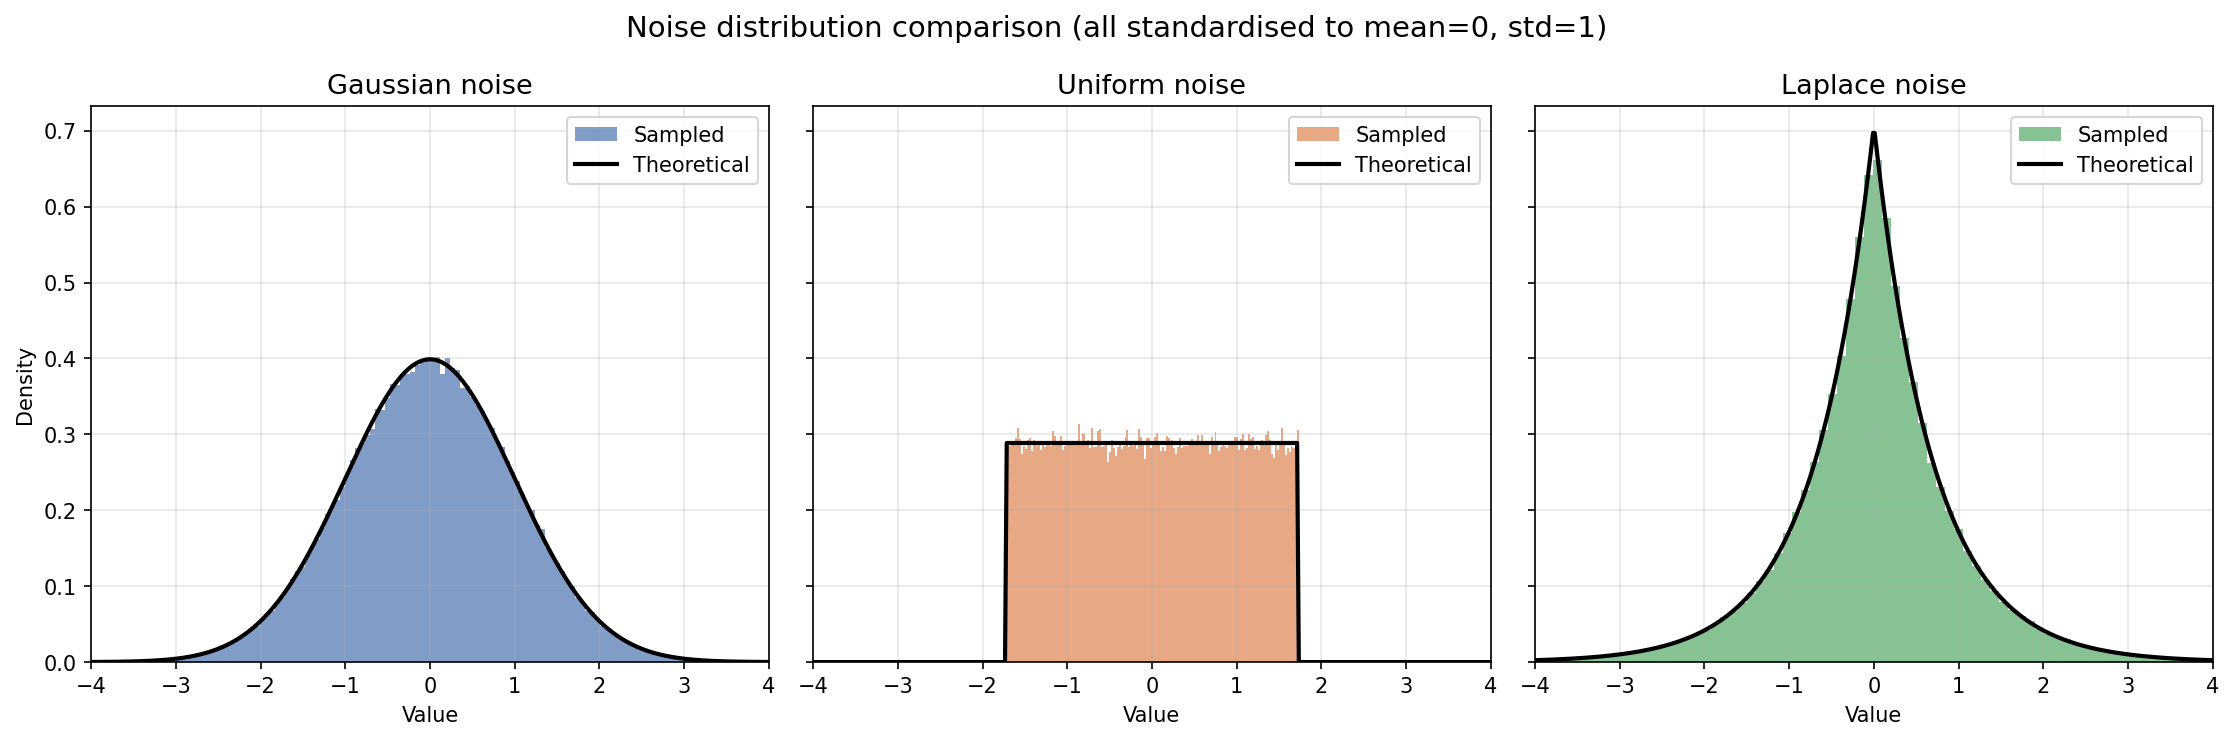

  samples_comparison.png


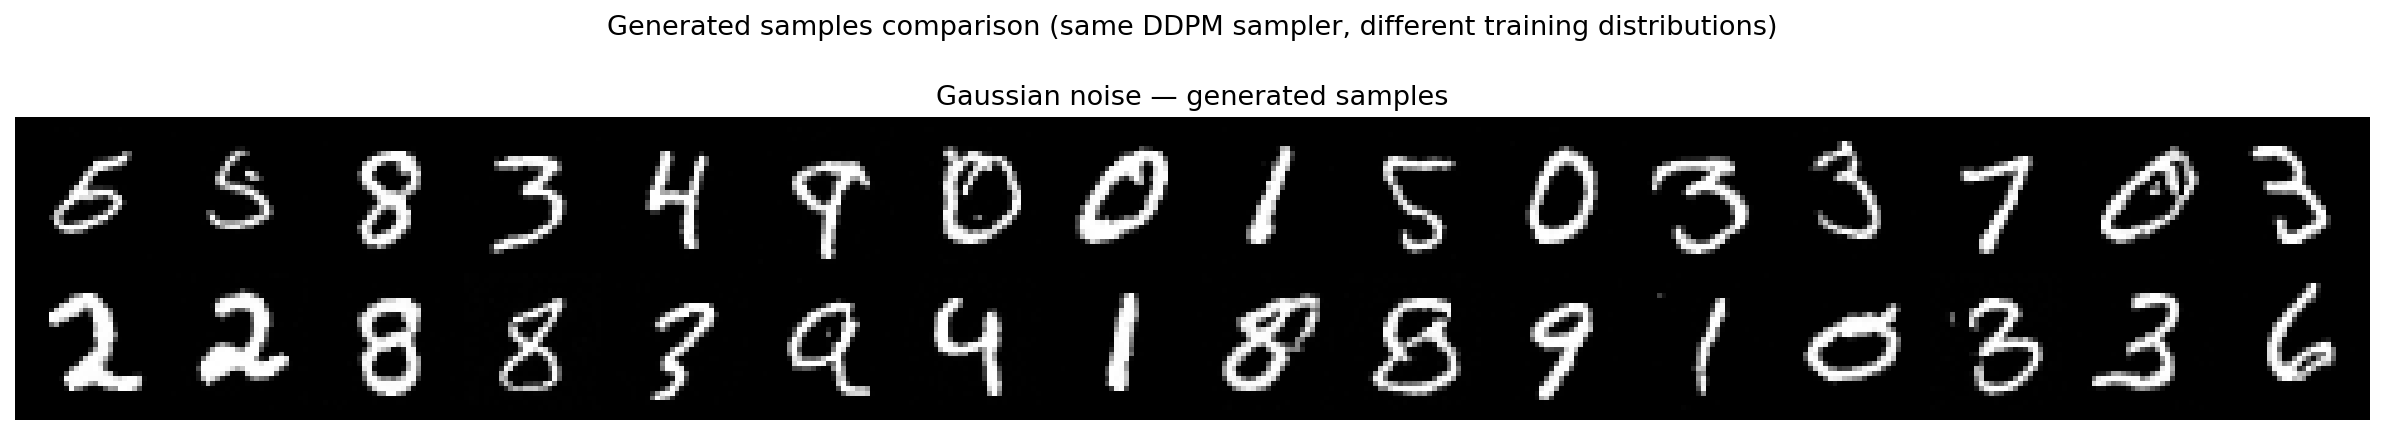

  trajectories.png


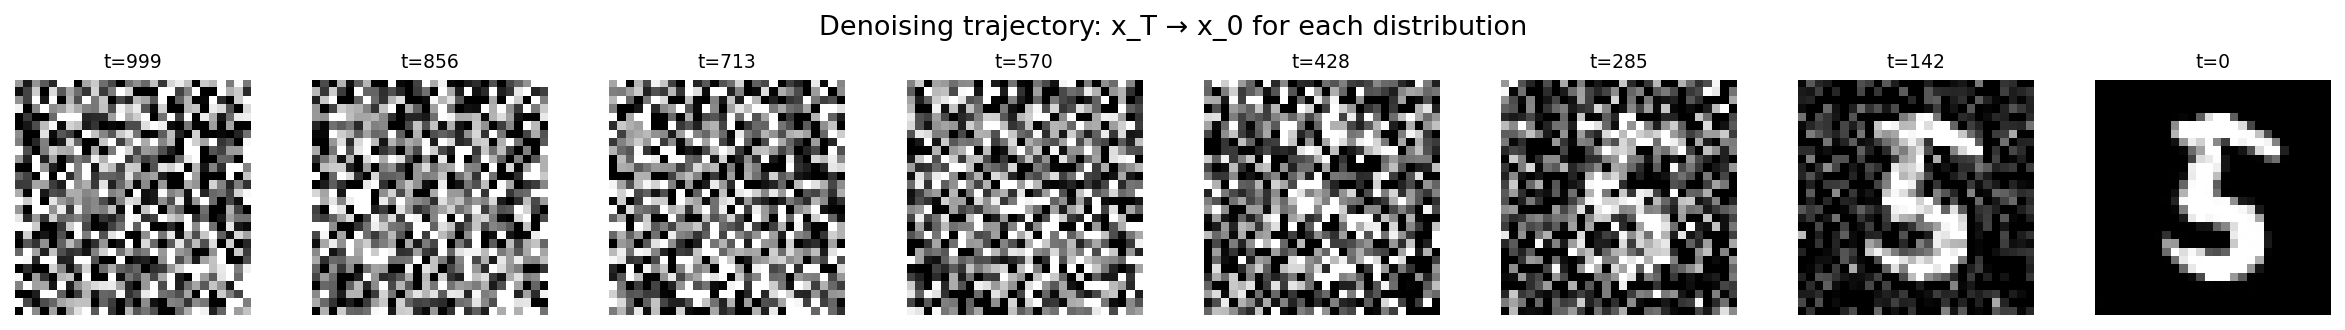

In [38]:
from IPython.display import Image, display

fig_dir = os.path.join(PROJECT_DIR, 'figures')
fig_files = sorted(os.listdir(fig_dir))

print(f'Found {len(fig_files)} figures:')
for f in fig_files:
    print(f'  {f}')
    display(Image(os.path.join(fig_dir, f), width=900))

## 2. Publication Summary Figure
A single 4-panel figure suitable for a report.

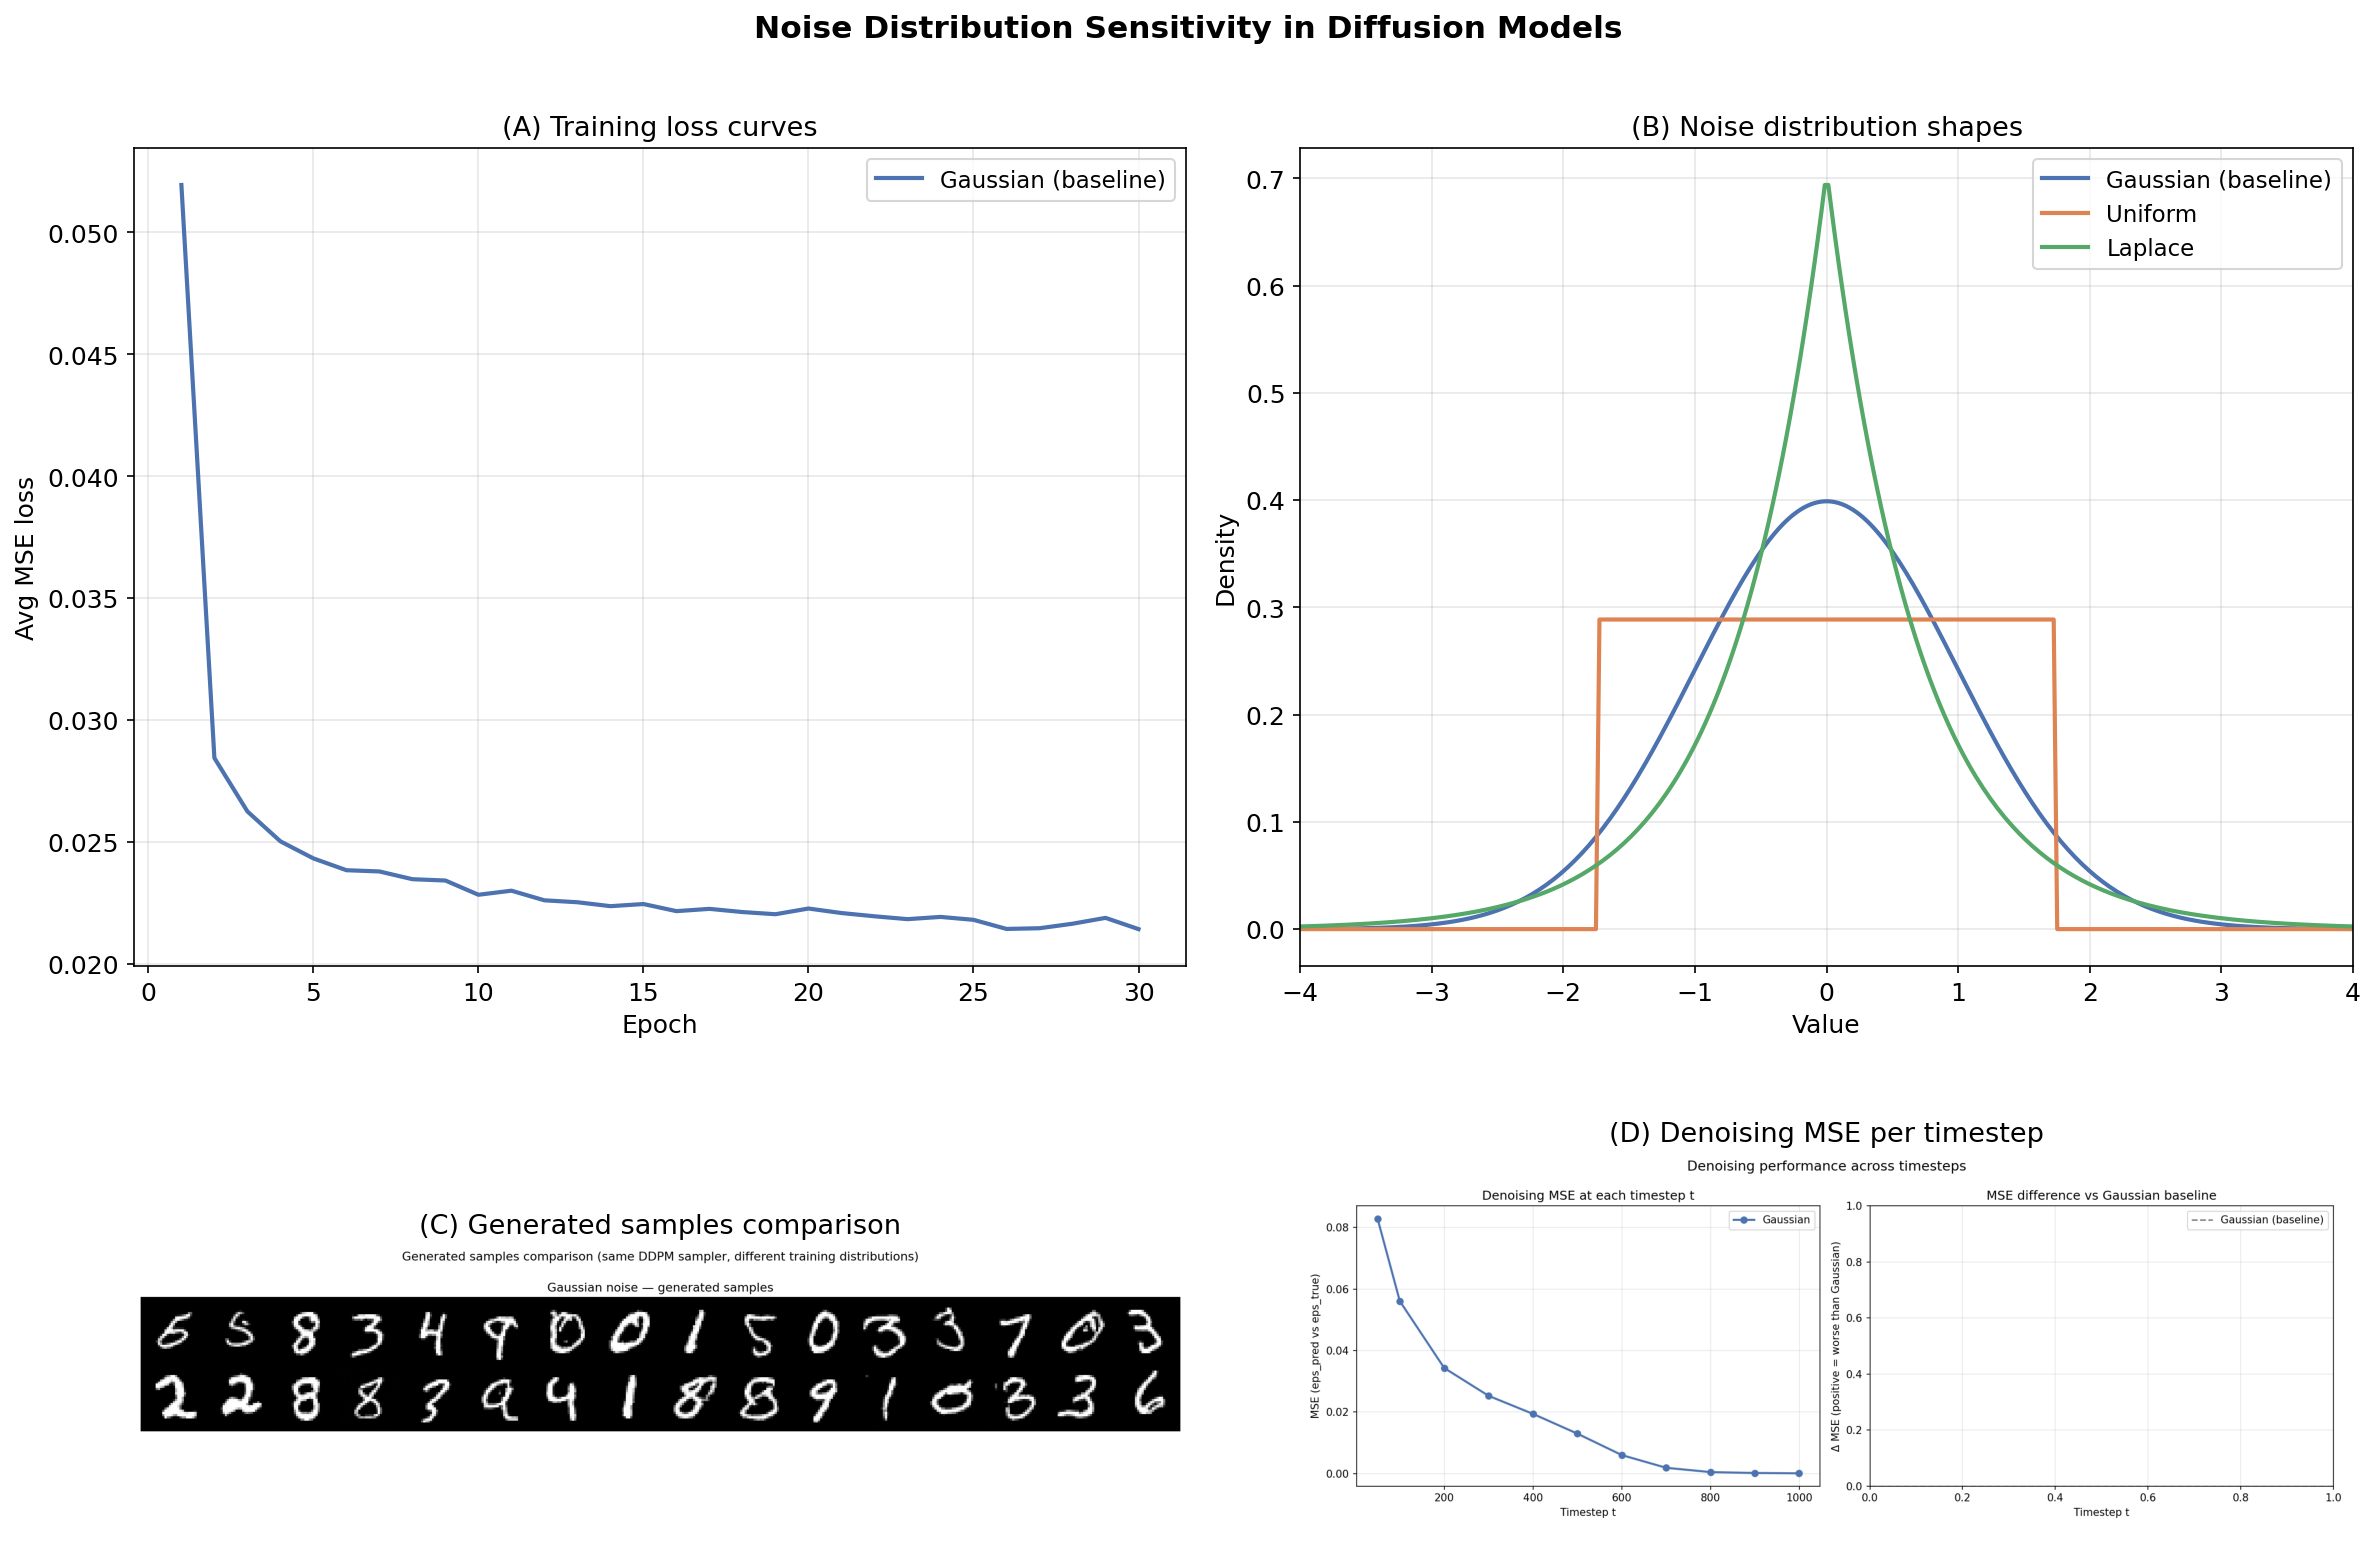

Summary figure saved.


In [39]:
fig = plt.figure(figsize=(16, 12))

# Panel A: Training curves
ax_a = fig.add_subplot(2, 2, 1)
for nt in NOISE_TYPES:
    log_path = os.path.join(PROJECT_DIR, 'logs', f'{nt}_loss.csv')
    if not os.path.exists(log_path):
        continue
    epochs, losses = [], []
    with open(log_path) as f:
        for row in csv.DictReader(f):
            epochs.append(int(row['epoch']))
            losses.append(float(row['epoch_avg_loss']))
    ax_a.plot(epochs, losses, color=COLORS[nt], label=LABELS[nt], linewidth=2)
ax_a.set_title('(A) Training loss curves')
ax_a.set_xlabel('Epoch'); ax_a.set_ylabel('Avg MSE loss')
ax_a.legend(); ax_a.grid(True, alpha=0.3)

# Panel B: Noise distributions
ax_b = fig.add_subplot(2, 2, 2)
x_range = np.linspace(-4, 4, 300)
pdfs = {
    'gaussian': np.exp(-x_range**2/2) / np.sqrt(2*np.pi),
    'uniform':  np.where(np.abs(x_range) <= 3**0.5, 1/(2*3**0.5), 0),
    'laplace':  np.exp(-np.abs(x_range)/2**-0.5) / (2*2**-0.5),
}
for nt, pdf in pdfs.items():
    ax_b.plot(x_range, pdf, color=COLORS[nt], label=LABELS[nt], linewidth=2)
ax_b.set_title('(B) Noise distribution shapes')
ax_b.set_xlabel('Value'); ax_b.set_ylabel('Density')
ax_b.set_xlim(-4, 4); ax_b.legend(); ax_b.grid(True, alpha=0.3)

# Panel C: Sample grids (load saved images)
ax_c = fig.add_subplot(2, 2, 3)
sample_path = os.path.join(PROJECT_DIR, 'figures', 'samples_comparison.png')
if os.path.exists(sample_path):
    img = plt.imread(sample_path)
    ax_c.imshow(img)
    ax_c.set_title('(C) Generated samples comparison')
else:
    ax_c.text(0.5, 0.5, 'Run Notebook 5 first', ha='center', va='center', transform=ax_c.transAxes)
ax_c.axis('off')

# Panel D: MSE vs timestep (load if computed, else placeholder)
ax_d = fig.add_subplot(2, 2, 4)
mse_path = os.path.join(PROJECT_DIR, 'figures', 'mse_vs_timestep.png')
if os.path.exists(mse_path):
    img = plt.imread(mse_path)
    ax_d.imshow(img)
    ax_d.set_title('(D) Denoising MSE per timestep')
else:
    ax_d.text(0.5, 0.5, 'Run Notebook 5 first', ha='center', va='center', transform=ax_d.transAxes)
ax_d.axis('off')

plt.suptitle('Noise Distribution Sensitivity in Diffusion Models', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'summary_figure.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Summary figure saved.')

## 3. Written Analysis Template
Fill in your observations after running the experiments.

### 3.1 Training Dynamics

**Convergence speed** (which distribution reached low loss fastest?):
> *[Fill in after training — e.g. "Gaussian converged to 50% of initial loss by epoch X, Uniform by epoch Y..."]*

**Training stability** (any distributions show instability / spikes?):
> *[Fill in — e.g. "Laplace showed higher variance in step loss, possibly due to heavy-tailed noise..."]*

**Final loss values** (Gaussian vs alternatives):
> *[Fill in — record exact values from the summary table in Notebook 5]*

### 3.2 Denoising Performance

**At low t (small noise, t < 200):**
> *[e.g. "All distributions perform similarly at low t, suggesting the model easily denoises subtle corruption regardless of noise shape."]*

**At high t (large noise, t > 700):**
> *[e.g. "Gaussian and Laplace diverge at high t — Laplace MSE is X% higher, which may reflect the model's difficulty predicting heavy-tailed noise."]*

**Interpretation:**
> *[Connect to the diffusion model theory — at high t, the image is almost pure noise, so the noise shape matters more. At low t, the image structure dominates.]*

### 3.3 Sample Quality

**Visual quality** (sharpness, recognisability of digits):
> *[Describe what you see — e.g. "All three produce recognisable MNIST digits. Gaussian samples appear marginally sharper at fine detail levels..."]*

**Diversity** (are all 10 digit classes represented? Any mode collapse?):
> *[e.g. "Uniform noise samples show slightly lower diversity with heavy representation of 0s and 1s..."]*

**Artefacts** (noise, blurring, unusual patterns):
> *[e.g. "Laplace-trained model produces faint grid-like artefacts in some samples, possibly due to..."]*

### 3.4 Conclusions

**Main finding:**
> *[One sentence summary — e.g. "Diffusion models trained on MNIST are [robust / sensitive] to the choice of noise distribution, with [Gaussian / all distributions] achieving comparable denoising quality."]*

**Implications:**
> *[Discuss what this means for the field — does it support using alternatives? Does it show Gaussian is special?]*

**Limitations:**
> 1. MNIST is a simple, low-resolution dataset — results may differ on CIFAR-10 or higher-resolution tasks.
> 2. The DDPM sampler used during inference always uses Gaussian noise in the reverse step; a matched sampler may change outcomes.
> 3. 30 epochs may not be enough to fully converge for all distributions.

**Future directions:**
> 1. Repeat on CIFAR-10 to test at higher complexity.
> 2. Use a matched reverse sampler (sample from the same distribution used in training).
> 3. Test with reduced T (fewer diffusion steps) — see Bonus section below.

## 4. Bonus Ablation — Varying Number of Diffusion Steps T
Test whether alternative distributions perform relatively better with fewer steps.

In [40]:
# Paste full model + diffusion class definitions here (same as Notebooks 4 & 5)
# [Same copy-paste block as Notebook 5 — omitted here for brevity]
# After pasting, run the cells below.

print("Paste the class definitions from Notebook 5 here, then run the ablation cells.")

Paste the class definitions from Notebook 5 here, then run the ablation cells.


In [41]:
# Ablation: train a small model with T=100 and T=500 for each distribution
# This is a shorter run — 10 epochs, smaller model — just to observe trends.

ABLATION_T_VALUES = [100, 500, 1000]  # compare against baseline T=1000
ABLATION_EPOCHS = 10
ABLATION_MODEL_CHANNELS = 32  # smaller for speed

def run_ablation(noise_type, T, epochs=ABLATION_EPOCHS, channels=ABLATION_MODEL_CHANNELS):
    """
    Mini training run for ablation.
    Returns list of epoch average losses.
    """
    torch.manual_seed(42)

    sched = make_beta_schedule('linear', T, 1e-4, 0.02)
    diff = DIFFUSION_CLASSES[noise_type](sched, DEVICE)

    model = UNet(in_channels=1, model_channels=channels, channel_mults=(1, 2, 4)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    dataset = torchvision.datasets.MNIST(root='/content/data', train=True, download=True, transform=transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x_0, _ in loader:
            x_0 = x_0.to(DEVICE)
            t = diff.sample_timestep(x_0.shape[0])
            opt.zero_grad()
            x_t, eps = diff.q_sample(x_0, t)
            loss = F.mse_loss(model(x_t, t), eps)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        epoch_losses.append(running / len(loader))
        print(f'  {noise_type:10s} T={T:4d} epoch {epoch+1:2d}: {epoch_losses[-1]:.5f}')
    return epoch_losses

# NOTE: this cell will take ~20-40 min to run for all combinations.
# To save time, you can reduce ABLATION_T_VALUES or ABLATION_EPOCHS.
ablation_results = {}

for T in ABLATION_T_VALUES:
    ablation_results[T] = {}
    for nt in NOISE_TYPES:
        print(f'Running ablation: {nt}, T={T}')
        ablation_results[T][nt] = run_ablation(nt, T)

print('Ablation complete.')

Running ablation: gaussian, T=100
  gaussian   T= 100 epoch  1: 0.12663
  gaussian   T= 100 epoch  2: 0.07358
  gaussian   T= 100 epoch  3: 0.06669
  gaussian   T= 100 epoch  4: 0.06320
  gaussian   T= 100 epoch  5: 0.06184
  gaussian   T= 100 epoch  6: 0.06044
  gaussian   T= 100 epoch  7: 0.05920
  gaussian   T= 100 epoch  8: 0.05843
  gaussian   T= 100 epoch  9: 0.05786
  gaussian   T= 100 epoch 10: 0.05717
Running ablation: uniform, T=100
  uniform    T= 100 epoch  1: 0.12382
  uniform    T= 100 epoch  2: 0.07152
  uniform    T= 100 epoch  3: 0.06478
  uniform    T= 100 epoch  4: 0.06126
  uniform    T= 100 epoch  5: 0.05976
  uniform    T= 100 epoch  6: 0.05819
  uniform    T= 100 epoch  7: 0.05705
  uniform    T= 100 epoch  8: 0.05610
  uniform    T= 100 epoch  9: 0.05535
  uniform    T= 100 epoch 10: 0.05447
Running ablation: laplace, T=100
  laplace    T= 100 epoch  1: nan
  laplace    T= 100 epoch  2: nan
  laplace    T= 100 epoch  3: nan
  laplace    T= 100 epoch  4: nan
  la

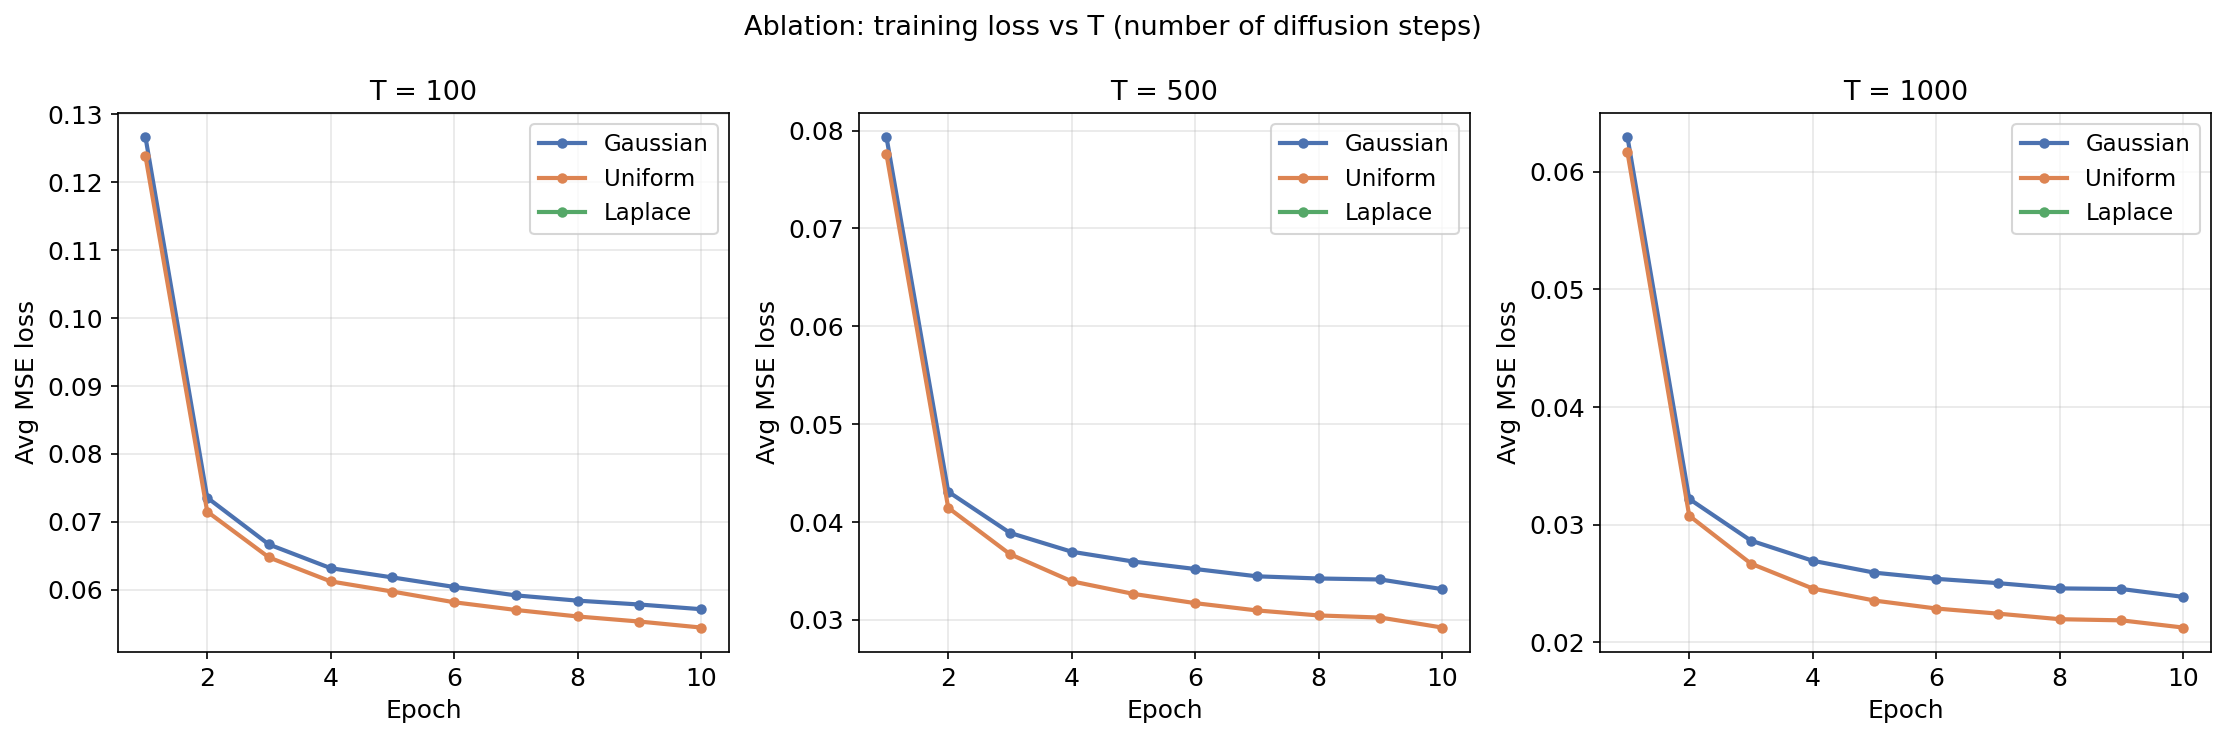

In [42]:
# Plot ablation results
fig, axes = plt.subplots(1, len(ABLATION_T_VALUES), figsize=(15, 5), sharey=False)

for ax, T in zip(axes, ABLATION_T_VALUES):
    for nt in NOISE_TYPES:
        if nt not in ablation_results.get(T, {}):
            continue
        losses = ablation_results[T][nt]
        ax.plot(range(1, len(losses)+1), losses,
                marker='o', markersize=4, color=COLORS[nt],
                label=nt.capitalize(), linewidth=2)
    ax.set_title(f'T = {T}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Avg MSE loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Ablation: training loss vs T (number of diffusion steps)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'ablation_T.png'), dpi=150)
plt.show()

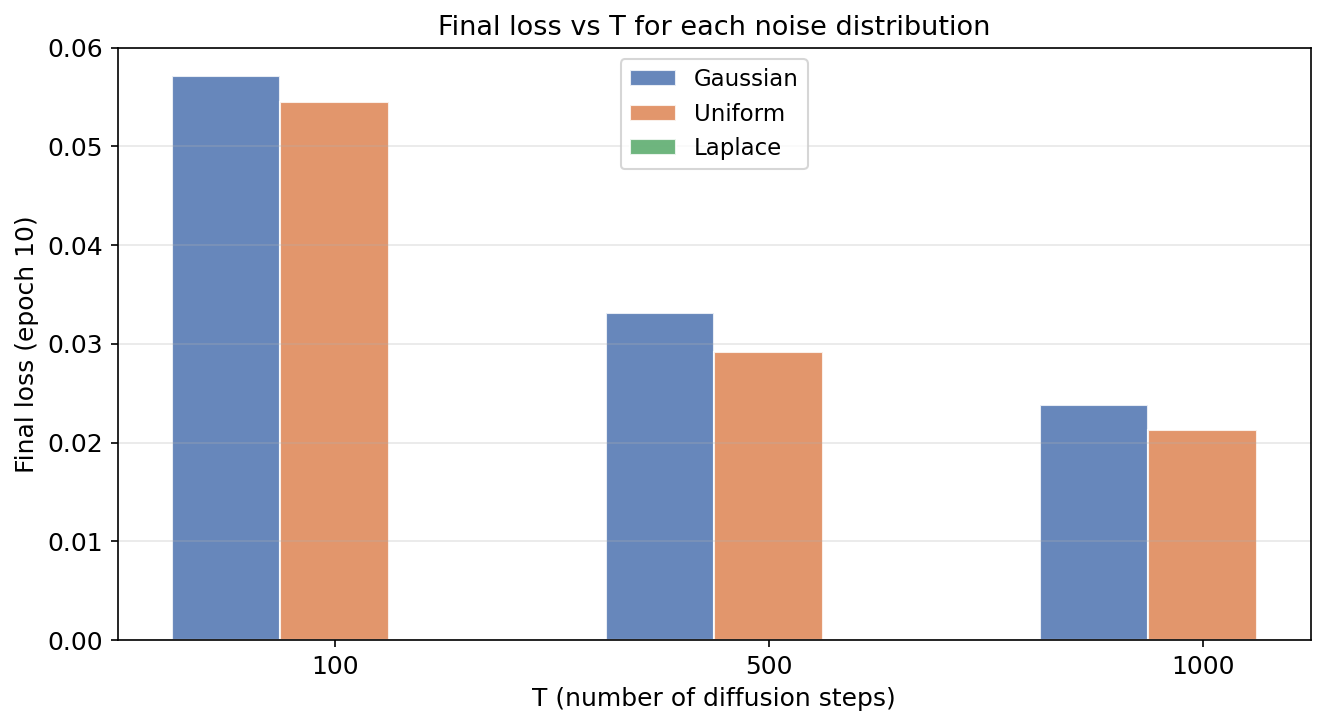

In [43]:
# Final loss comparison across T
fig, ax = plt.subplots(figsize=(9, 5))
bar_width = 0.25
x = np.arange(len(ABLATION_T_VALUES))

for i, nt in enumerate(NOISE_TYPES):
    final_losses = [
        ablation_results[T][nt][-1] if nt in ablation_results.get(T, {}) else float('nan')
        for T in ABLATION_T_VALUES
    ]
    ax.bar(x + i * bar_width, final_losses, bar_width,
           label=nt.capitalize(), color=COLORS[nt], alpha=0.85, edgecolor='white')

ax.set_xlabel('T (number of diffusion steps)')
ax.set_ylabel(f'Final loss (epoch {ABLATION_EPOCHS})')
ax.set_title('Final loss vs T for each noise distribution')
ax.set_xticks(x + bar_width)
ax.set_xticklabels([str(T) for T in ABLATION_T_VALUES])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'ablation_bar.png'), dpi=150)
plt.show()

## 5. File Index — Everything Saved to Drive

In [44]:
print('=== PROJECT OUTPUT INDEX ===')
print()

for root, dirs, files in os.walk(PROJECT_DIR):
    dirs.sort()
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root) if level > 0 else 'diffusion_noise_project'
    print(f'{indent}{folder_name}/')
    subindent = '  ' * (level + 1)
    for f in sorted(files):
        size_kb = os.path.getsize(os.path.join(root, f)) / 1024
        print(f'{subindent}{f} ({size_kb:.1f} KB)')

print()
print('Project complete!')

=== PROJECT OUTPUT INDEX ===

diffusion_noise_project/
  config.json (0.4 KB)
  unet.py (3.3 KB)
  checkpoints/
    gaussian/
      epoch_005.pt (76814.7 KB)
      epoch_010.pt (76856.0 KB)
      epoch_015.pt (76897.3 KB)
      epoch_020.pt (76938.5 KB)
      epoch_025.pt (76979.8 KB)
      epoch_030.pt (77021.1 KB)
    laplace/
    uniform/
  figures/
    ablation_T.png (120.8 KB)
    ablation_bar.png (47.0 KB)
    beta_schedule.png (99.8 KB)
    forward_diffusion_comparison.png (82.3 KB)
    gaussian_loss.png (86.5 KB)
    loss_comparison.png (85.6 KB)
    mnist_samples.png (29.8 KB)
    mse_vs_timestep.png (91.7 KB)
    noise_distributions.png (90.4 KB)
    samples_comparison.png (59.9 KB)
    summary_figure.png (315.3 KB)
    trajectories.png (46.8 KB)
  logs/
    gaussian_loss.csv (1.7 KB)
  samples/
    gaussian_final.png (90.1 KB)

Project complete!
